<a href="https://colab.research.google.com/github/ryan-de-melo/graph-theory/blob/main/exercises_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício prático de Teoria dos Grafos

Usa-se o dataset do YELP

In [33]:
# @title Instalação
!pip install parameterized
import os.path as opath
if not opath.exists('gtufcg'):
 !git clone https://github.com/pdlmachado/gtufcg.git > /dev/null 2>&1
else:
 !cd gtufcg && git pull > /dev/null 2>&1
import networkx as nx
# Pacotes auxiliares
import matplotlib.pyplot as plt
from colour import Color
white = Color("white")
from gtufcg.util.get_util import get_edge
from gtufcg.util.draw_util import drawgv_graph_vs, create_graph_img, drawgv_duo
from gtufcg.util.draw_util import draw_graph, drawgv_graph
import warnings
warnings.filterwarnings('ignore')
from matplotlib import colors

from parameterized import parameterized
print("Instalação concluída!")

Instalação concluída!


## Importação de funcões e grafos

A primeira questão solicita uma função que recebe um grafo YELP e ela deve retornar um multigrafo que possua vértices de usuários e suas arestas devem ser negocios que ambos usuários fizeram avaliações.

In [34]:
from itertools import combinations

def co_reviewers(g: nx.Graph) -> nx.MultiGraph:
    returnGraph = None

    if g is not None:
        returnGraph = nx.MultiGraph()
        add_users_from(g, returnGraph)

        for business, data in g.nodes(data = True):
            if data["type"] == "business":
                reviewers = []

                for neighbor in g.neighbors(business):
                    if g.nodes[neighbor].get("type") == "user":
                        reviewers.append(neighbor)

                if len(reviewers) >= 2:
                    for user1, user2 in combinations(reviewers, 2):    # cria as combinações de co-revisores
                        returnGraph.add_edge(user1, user2, business = business)

        if len(returnGraph) == 0:
            returnGraph = None

    return returnGraph

"""
    Adiciona em um multigrafo todos os vertices que são usuarios de um grafo base
"""
def add_users_from(base: nx.Graph, g: nx.MultiGraph) -> None:
    if g is not None and base is not None:
        for node, data in base.nodes(data = True):
            if data["type"] == "user":
                g.add_node(node)

[('2WnXYQFK0hXEoTxPtV2zvg', {}), ('qVc8ODYU5SZjKXVBgXdI7w', {}), ('xoZvMJPDW6Q9pDAXI0e_Ww', {}), ('MGPQVLsODMm9ZtYQW-g_OA', {}), ('SZDeASXq7o05mMNLshsdIA', {}), ('SgiBkhXeqIKl1PlFpZOycQ', {}), ('1L3O2CUTk27SnmqyPBWQdQ', {}), ('j14WgRoU_-2ZE1aw1dXrJg', {})]
[('2WnXYQFK0hXEoTxPtV2zvg', 'qVc8ODYU5SZjKXVBgXdI7w', {'business': '-OKB11ypR4C8wWlonBFIGw'}), ('2WnXYQFK0hXEoTxPtV2zvg', 'xoZvMJPDW6Q9pDAXI0e_Ww', {'business': '-OKB11ypR4C8wWlonBFIGw'}), ('qVc8ODYU5SZjKXVBgXdI7w', 'xoZvMJPDW6Q9pDAXI0e_Ww', {'business': '-OKB11ypR4C8wWlonBFIGw'}), ('MGPQVLsODMm9ZtYQW-g_OA', 'SgiBkhXeqIKl1PlFpZOycQ', {'business': '_ab50qdWOk0DdB6XOrBitw'}), ('MGPQVLsODMm9ZtYQW-g_OA', 'j14WgRoU_-2ZE1aw1dXrJg', {'business': '_ab50qdWOk0DdB6XOrBitw'}), ('SZDeASXq7o05mMNLshsdIA', 'SgiBkhXeqIKl1PlFpZOycQ', {'business': 'iSRTaT9WngzB8JJ2YKJUig'}), ('SZDeASXq7o05mMNLshsdIA', '1L3O2CUTk27SnmqyPBWQdQ', {'business': 'iSRTaT9WngzB8JJ2YKJUig'}), ('SgiBkhXeqIKl1PlFpZOycQ', 'j14WgRoU_-2ZE1aw1dXrJg', {'business': '_ab50qdWOk0DdB6XO

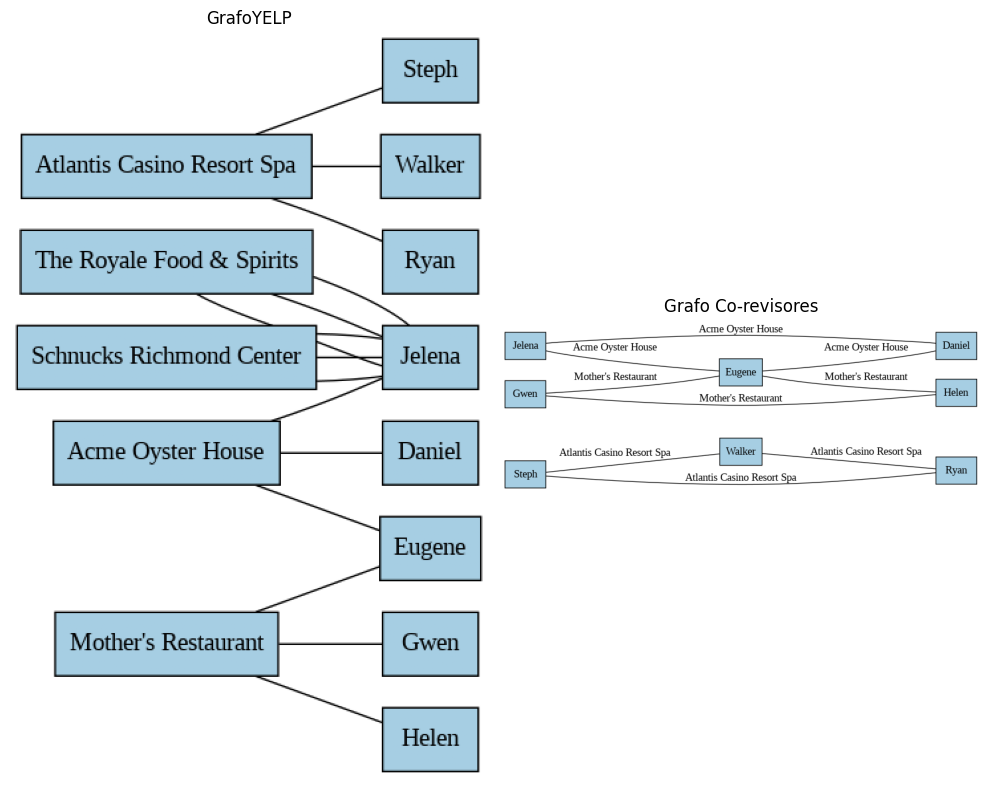

In [35]:
# Main para a questão 1

name = "s_25_5.graphml"
G = nx.read_graphml("graphs/"+name, force_multigraph=True)
C = co_reviewers(G)

# Imprimindo vértices e arestas do grapo de co-revisores
print(C.nodes(data=True))
print(C.edges(data=True))

# Imprimindo vértices e arestas do grafo de co-revisores (com labels para facilitar visualização)
print([G.nodes[n]['label'] for n in C.nodes])
print([f'({G.nodes[x]['label']}, {G.nodes[y]['label']}, "business": {G.nodes[C[x][y][k]["business"]]['label']})' for x,y,k in C.edges])

# Visualização
GV = create_graph_img(G, layoutid="dot", shape="box", width=10, height=10, with_node_labels=True)
for u in C.nodes:
    C.nodes[u]['label'] = G.nodes[u]['label']
for x, y, k in C.edges:
    b = C[x][y][k]['business']
    C[x][y][k]['label'] = G.nodes[b]['label']
CV = create_graph_img(C, layoutid="dot", shape="box", with_edge_labels=True, width=100, height=100, with_node_labels=True)
drawgv_duo(GV, CV, title1="GrafoYELP", title2="Grafo Co-revisores",
           width=10, height=8)


In [36]:
# Testes para a questão 1

############################
# Execute no terminal: python -m unittest test/test_Q01.py
########################################
import unittest
import networkx as nx
from parameterized import parameterized

# Test Data
g_s_5_5 = nx.read_graphml("graphs/s_5_5.graphml", force_multigraph=True)
g_s_10_10 = nx.read_graphml("graphs/s_10_10.graphml", force_multigraph=True)
g_s_25_5 = nx.read_graphml("graphs/s_25_5.graphml", force_multigraph=True)
g_s_50_5 = nx.read_graphml("graphs/s_50_5.graphml", force_multigraph=True)
g_state_IL_city_Lincoln = nx.read_graphml("graphs/IL/state_IL_city_Lincoln.graphml", force_multigraph=True)
g_state_IL_city_Dupo = nx.read_graphml("graphs/IL/state_IL_city_Dupo.graphml",force_multigraph=True)

## Funções auxiliares
# Recupera o nome da variável global para identificar dados do teste que falha
def get_var_name(var):
    for name, value in globals().items():
        if value is var:
            return name
# Retorna o identificador de um vértice a partir do label
def get_Id(g, label):
    for u in g.nodes:
        if g.nodes[u]['label']==label:
            return u

class TestClass_Co_reviewers(unittest.TestCase):

    @parameterized.expand([
        [g_s_5_5, ['Sophia', 'Debra'], []],
        [g_s_10_10, ['John', 'Walker', 'Daniel', 'Steph', 'Mike', 'Gwen', 'Jane'],
                    [('Walker', 'Daniel', 0, 'Reading Terminal Market'),
                     ('Walker', 'Daniel', 1, 'Philadelphia Museum of Art'),
                     ('Walker', 'Steph', 0, 'Atlantis Casino Resort Spa'),
                     ('Walker', 'Jane', 0, '30th Street Station'),
                     ('Daniel', 'Gwen', 0, 'The Praline Connection'),
                     ('Daniel', 'Gwen', 1, 'French Market')]],
        [g_s_25_5, ['Jelena', 'Eugene', 'Daniel', 'Walker', 'Ryan', 'Steph', 'Gwen', 'Helen'],
                   [('Jelena', 'Eugene', 0, 'Acme Oyster House'),
                    ('Jelena', 'Daniel', 0, 'Acme Oyster House'),
                    ('Eugene', 'Daniel', 0, 'Acme Oyster House'),
                    ('Eugene', 'Gwen', 0, "Mother's Restaurant"),
                    ('Eugene', 'Helen', 0, "Mother's Restaurant"),
                    ('Walker', 'Ryan', 0, 'Atlantis Casino Resort Spa'),
                    ('Walker', 'Steph', 0, 'Atlantis Casino Resort Spa'),
                    ('Ryan', 'Steph', 0, 'Atlantis Casino Resort Spa'),
                    ('Gwen', 'Helen', 0, "Mother's Restaurant")]],
        [g_s_50_5, ['Ryan', 'Steph', 'Walker', 'Jenna', 'John', 'Peyman', 'Lia', 'Jane', 'Eugene', 'Helen', 'Jelena', 'Sherri', 'Daniel'],
                   [('Ryan', 'Steph', 0, 'Atlantis Casino Resort Spa'),
                    ('Ryan', 'Walker', 0, 'Atlantis Casino Resort Spa'),
                    ('Steph', 'Walker', 0, 'Atlantis Casino Resort Spa'),
                    ('Walker', 'Lia', 0, '30th Street Station'),
                    ('Walker', 'Jane', 0, '30th Street Station'),
                    ('Jenna', 'John', 0, 'Village Whiskey'),
                    ('Jenna', 'Peyman', 0, 'Village Whiskey'),
                    ('John', 'Peyman', 0, 'Village Whiskey'),
                    ('Lia', 'Jane', 0, '30th Street Station'),
                    ('Lia', 'Eugene', 0, "Commander's Palace"),
                    ('Lia', 'Helen', 0, "Commander's Palace"),
                    ('Eugene', 'Helen', 0, "Commander's Palace"),
                    ('Eugene', 'Jelena', 0, 'Acme Oyster House'),
                    ('Eugene', 'Sherri', 0, 'Acme Oyster House'),
                    ('Eugene', 'Daniel', 0, 'Acme Oyster House'),
                    ('Jelena', 'Sherri', 0, 'Acme Oyster House'),
                    ('Jelena', 'Daniel', 0, 'Acme Oyster House'),
                    ('Sherri', 'Daniel', 0, 'Acme Oyster House')]],
        [g_state_IL_city_Lincoln, ['V', 'Diana', 'Gigi', 'Elizabeth', 'Angela'],
                                  [('V', 'Diana', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('V', 'Gigi', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('V', 'Elizabeth', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('V', 'Angela', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('Diana', 'Gigi', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('Diana', 'Elizabeth', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('Diana', 'Angela', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('Gigi', 'Elizabeth', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('Gigi', 'Angela', 0, 'Helitech Waterproofing & Foundation Repair'),
                                   ('Elizabeth', 'Angela', 0, 'Helitech Waterproofing & Foundation Repair')]]
    ])
    def test_base(self, g, e_nodes, e_edges):
        var_name = get_var_name(g)
        result = co_reviewers(g)
        # Converte labels da saída esperada em identificadores
        e_id_nodes = [get_Id(g,l) for l in e_nodes]
        e_id_edges = [(get_Id(g,x),get_Id(g,y),k,get_Id(g,b)) for x,y,k,b in e_edges]
        # Verifica o grafo retornado
        self.assertCountEqual(result.nodes, e_id_nodes, f"Grafo: {var_name}, vértices: {e_nodes}")
        self.assertTrue(all(any(((x==u and y==v) or (x==v) and (y==u)) and (b==result[x][y][k]['business'])  for u,v,j,b in e_id_edges) for x,y,k in result.edges))
        self.assertTrue(all(any(((x==u and y==v) or (x==v) and (y==u)) and (b==result[x][y][k]['business'])  for x,y,k in result.edges) for u,v,j,b in e_id_edges))

    def test_None(self):
        self.assertIsNone(co_reviewers(None))

    def test_null(self):
        self.assertIsNone(co_reviewers(nx.MultiGraph()))

    def test_graph_structure(self):
        #Testa se o resultado é um MultiGraph com propriedade 'business' nas arestas.
        result = co_reviewers(g_state_IL_city_Dupo)
        # Verifica se o resultado é um MultiGraph
        self.assertIsInstance(result, nx.MultiGraph)
        # Verifica se todas as arestas possuem a propriedade 'business'
        edge_data = [data for u, v, k, data in result.edges(keys=True, data=True)]
        self.assertTrue(all('business' in data for data in edge_data), f"Alguma aresta sem propriedade 'business'")
        self.assertTrue(all(data['business'] is not None for data in edge_data), f"Alguma aresta tem valor None em 'business'")

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], verbosity=2, exit=False)

test_None (__main__.TestClass_Co_reviewers.test_None) ... ok
test_base_0 (__main__.TestClass_Co_reviewers.test_base_0) ... ok
test_base_1 (__main__.TestClass_Co_reviewers.test_base_1) ... ok
test_base_2 (__main__.TestClass_Co_reviewers.test_base_2) ... ok
test_base_3 (__main__.TestClass_Co_reviewers.test_base_3) ... ok
test_base_4 (__main__.TestClass_Co_reviewers.test_base_4) ... ok
test_graph_structure (__main__.TestClass_Co_reviewers.test_graph_structure) ... ok
test_null (__main__.TestClass_Co_reviewers.test_null) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.016s

OK
